<a href="https://colab.research.google.com/github/litlig/notebooks/blob/main/resnet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ResNet paper https://arxiv.org/pdf/1512.03385

#### How did the idea emerge?
The work was to solve the degradation issue for deep nn. When nn depth grows beyond a certain limit, its training error rate is higher than a narrower model. The deeper nn have more capacity, it can at least achieve the same perf by copy the structure for a narrower nn, and for extra layers just using an identity linear transformation. For some reason, the optimization on a deep nn failed to reach this manually constructed better solution, but converge to a sub-optimal solution. Resnet adds skip connections every few layers, so the network can easily skip certain layers if that is better.

#### Formulation
With the skip link added, the nn stack is approximating a residual $H(x)-x$.
>To the extreme, if an identity mapping were optimal, it would be easier to push the residual to zero than to fit an identity mapping by a stack of nonlinear layers.

#### Confusion and questions:
1. Is it true that it's difficult to use deep nn with non-linearity approximate a linear function?
2. Residual is based on the assumption that H(x) is largely an identity mapping. If H(x) is a linear but non-identical mapping, $H(x) = wX+b$, then the residual is $H(x) - x = (w-1)X+b$, and it does not seem to be an easier problem than the original. Does it mean the layer blocks in CNN are largely identity mapping?
3. Another benefit of resnet is letting gradient pass through in backward propagation, resolve the vanishing gradient issue. I want to see it in example.


In [28]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt

# a simple linear regression, x = wy
def get_batch(batch_size):
  x = torch.randn(batch_size, 2, dtype=torch.float32)
  w = torch.tensor([[2, 4],[3,2]], dtype=torch.float32)
  y = torch.matmul(x, w.T)
  return x, y

def train(model, steps=10000, lr=0.01):
  optimizer = optim.Adam(model.parameters(), lr=lr)
  losses = []
  model.train()
  for i in range(steps):
    x, y = get_batch(64)
    optimizer.zero_grad()
    loss = F.mse_loss(model(x), y)
    losses.append(loss.item())
    loss.backward()
    optimizer.step()

  return losses

def plot_losses(losses):
  plt.plot(losses)
  plt.xlabel("Iterations")
  plt.ylabel("Loss")
  plt.title("Training Loss over Iterations")
  plt.show()

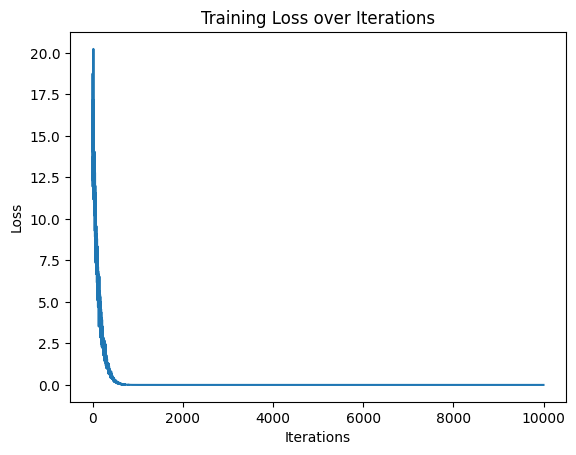

In [29]:
li_model = nn.Linear(2, 2)
li_loss = train(li_model)
plot_losses(li_loss)

In [30]:
li_model.weight

Parameter containing:
tensor([[2., 4.],
        [3., 2.]], requires_grad=True)

In [34]:
class Net(nn.Module):
  def __init__(self, residual = False, n_layer = 3):
    super(Net, self).__init__()
    self.mlp = nn.Sequential()
    for i in range(n_layer):
      self.mlp.append(nn.Linear(2, 2))
      self.mlp.append(nn.Sigmoid())
    self.mlp.append(nn.Linear(2, 2))
    self.residual = residual

  def forward(self, x):
    if self.residual:
      return x + self.mlp(x)
    return self.mlp(x)

In [37]:
nl_model = Net()
nl_loss = train(nl_model)
res_model = Net(residual=True)
res_loss = train(res_model)

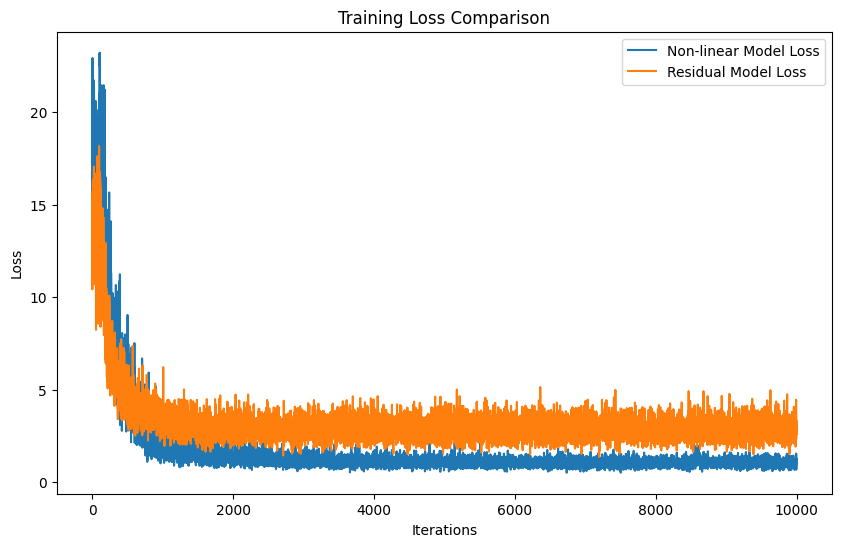

In [38]:
plt.figure(figsize=(10, 6))
plt.plot(nl_loss, label='Non-linear Model Loss')
plt.plot(res_loss, label='Residual Model Loss')
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()